# Intro to NumPy & Linear Algebra — Follow-Along

## Try me
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ffraile/computer_science_tutorials/blob/main/source/Applied%20Mathematics/class%20notes/Intro_to_NumPy_and_Linear_Algebra_follow_along.ipynb)[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/ffraile/computer_science_tutorials/main?labpath=source%2FApplied%20Mathematics%2Fclass%20notes%2FIntro_to_NumPy_and_Linear_Algebra_follow_along.ipynb)

This notebook blends **NumPy basics** with **Linear Algebra in NumPy**.
Use the **predict → run** habit: mentally predict outputs, then execute to check.


## 0) Setup
Import NumPy and create a random generator for reproducibility.

In [1]:

import numpy as np
_

''

(300, 451, 3)


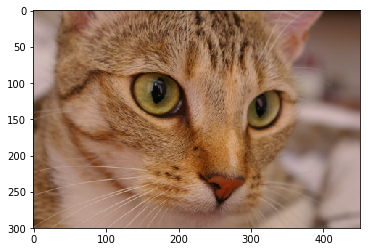

In [5]:
from skimage import data
import numpy as np
from matplotlib import pyplot as plt
cat = data.chelsea()
plt.imshow(cat)
print(cat.shape)

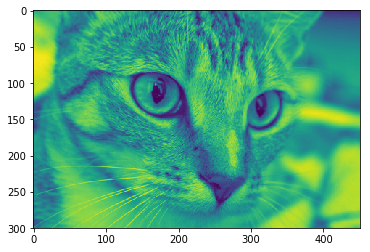

In [6]:
plt.imshow(cat[:,:,1]) # Only Green

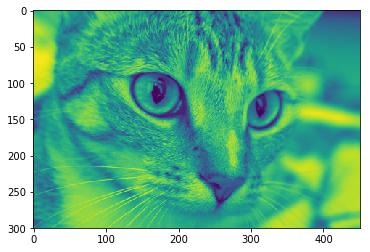

In [16]:

weights = np.array([[0.2126], [0.7152], [0.0722] ]) # Y=0.2126R+0.7152G+0.0722B
luminance = cat @ weights
plt.imshow(luminance.squeeze())



# Part A — NumPy Basics

Core concepts: creation, shapes/dtypes, indexing & slicing, boolean masks, broadcasting, vectorized ops, aggregations.

## Key ideas
- **Numpy arrays**: multidimensional, fixed-type containers for numbers.
- **Array programming**: think in terms of whole arrays, not elementwise loops.


### A1) Creating arrays
- From Python objects: ```np.array([1,2,3])```
- Ranges/grids: ```np.arange```, ```np.linspace```
- Filled arrays: ```np.zeros```, ```np.ones```, ```np.full```, ```np.eye```
- Random: ```rng.integers```, ```rng.normal```, ```rng.random```
- ```dtype``` used to force or read the type

In [ ]:

a = np.array([1, 2, 3])
b = np.arange(0, 10, 2)        # step range
c = np.linspace(0, 1, 5)       # 5 points in [0,1]
Z = np.zeros((2,3))
O = np.ones((3,2))
F = np.full((2,2), 7.5)
I = np.eye(3)
R = np.random.normal(loc=0, scale=1, size=(3,2))

print("a:", a, a.dtype)
print("b:", b)
print("c:", c)
print("Z:\n", Z)
print("I:\n", I)
print("R:\n", R)

### A2) Shape, dtype, size
- `.shape`, `.ndim`, `.size`, `.dtype`, `.itemsize`
- `astype` converts dtype

In [ ]:

M = np.random.normal(0, 100, size=(3,4))
print("shape:", M.shape, "| ndim:", M.ndim, "| size:", M.size)
print("dtype:", M.dtype, "| itemsize:", M.itemsize, "bytes")
print("astype float32:\n", M.astype(np.float32))

### A3) Indexing, slicing, boolean masks
- 1D: `x[i]`, `x[i:j:k]`
- 2D: `A[i, j]`, `A[i, j1:j2]`, row/col slices
- Masks: `mask = (A % 2 == 0)` → `A[mask]`

In [4]:

x = np.arange(10)
A = np.random.normal(0, 20, size=(4,5))
print("x:", x)
print("x[2:8:2]:", x[2:8:2])
print("A:\n", A)
print("A[1, :]:", A[1, :])
print("A[:, 2]:", A[:, 2])

mask = (A > 10)
print("mask as 0/1:\n", mask.astype(int))
print("A[mask]:", A[mask])

x: [0 1 2 3 4 5 6 7 8 9]
x[2:8:2]: [2 4 6]
A:
 [[ 15.1126147    8.32440394  26.91619507 -27.66382784 -22.93165055]
 [-16.89765775  -7.04395678 -13.29242426 -18.80939527 -10.25047936]
 [ -7.62540901  71.28512664 -23.06769533  -8.5883721   28.20040049]
 [ 48.10698379 -37.64323192  -4.02617661  40.57818012 -25.29639523]]
A[1, :]: [-16.89765775  -7.04395678 -13.29242426 -18.80939527 -10.25047936]
A[:, 2]: [ 26.91619507 -13.29242426 -23.06769533  -4.02617661]
mask as 0/1:
 [[1 0 1 0 0]
 [0 0 0 0 0]
 [0 1 0 0 1]
 [1 0 0 1 0]]
A[mask]: [15.1126147  26.91619507 71.28512664 28.20040049 48.10698379 40.57818012]


In [ ]:
# Mini challenge
# Print the two first rows of A

# Use a mask to find the values of A that are lower than 0

### A4) Broadcasting
- Fancy word, just extends a constant or array so that it matches the shape of another array
- Align shapes **from the right**; dims are compatible if equal or either is `1`.

In [6]:

B = np.ones((3,4))
row = np.array([1, 0, -1, 2])     # shape (4,)
col = np.array([[10],[20],[30]])  # shape (3,1)

print("B:\n", B)
print("B + row:\n", B + row)   # across rows
print("B + col:\n", B + col)   # down columns

B:
 [[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]
B + row:
 [[2. 1. 0. 3.]
 [2. 1. 0. 3.]
 [2. 1. 0. 3.]]
B + col:
 [[11. 11. 11. 11.]
 [21. 21. 21. 21.]
 [31. 31. 31. 31.]]


### A5) Vectorized ops, ufuncs, aggregations
- Elementwise: `+ - * / **`
- Ufuncs: `np.sqrt`, `np.exp`, `np.clip`, `np.where`
- Aggregations: `np.sum`, `np.mean`, `np.std` with `axis=`

In [ ]:

X = np.linspace(-2, 2, 5)
print("X:", X)
print("X**2:", X**2)
print("sqrt(abs(X)):", np.sqrt(np.abs(X)))
print("where(X>=0, 1, -1):", np.where(X>=0, 1, -1))

G = np.random.randint()
print("G:\n", G)
print("sum all:", np.sum(G))
print("mean per col:", np.mean(G, axis=0))
print("std per row:", np.std(G, axis=1))

### A-PI Cards (predict; then run the check cell)

**Card A1 — Slicing vs copying**
```python
A = np.arange(9).reshape(3,3)
B = A[0, :]      # view or copy?
B[0] = 99
```
What changes in `A`?

In [ ]:

A = np.arange(9).reshape(3,3)
B = A[0, :]
B[0] = 99
print("A:\n", A)  # A[0,0] becomes 99 because B is a view (slice)

**Card A2 — Mask + broadcasting**
```python
X = np.array([[-1,0,1],[2,-2,3]])
X[X<0] = X[X<0] + 10
```
Predict final `X`.

In [ ]:

X = np.array([[-1,0,1],[2,-2,3]])
X[X<0] = X[X<0] + 10
print(X)

**Card A3 — Axis confusion**
For `A.shape == (4,5,6)`, what shape is `np.sum(A, axis=1)`?

In [ ]:

A = np.zeros((4,5,6))
print("sum axis=1 ->", np.sum(A, axis=1).shape)  # (4,6)

# Part B — Linear Algebra with NumPy

Dot/matrix products, transpose/reshape, norms, solving linear systems, and quick intros to determinant, inverse, eigen, SVD.

### B1) Dot (scalar) product
`a @ b` or `np.dot(a,b)` for 1-D vectors.

In [ ]:

a = np.array([1.,2.,3.])
b = np.array([4.,5.,6.])
print("a@b:", a @ b)
print("np.dot:", np.dot(a,b))

### B2) Matrix product
If `A` is `(m, p)` and `B` is `(p, n)`, then `A @ B` is `(m, n)`.

In [ ]:

A = np.array([[1,2,3],
              [4,5,6]], dtype=float)   # (2,3)
B = np.array([[1, 0],
              [0, 1],
              [1,-1]], dtype=float)    # (3,2)
C = A @ B
print("C shape:", C.shape, "\nC=\n", C)

### B3) Transpose & reshape
- 2-D transpose: `A.T`
- General axis permute: `np.transpose(A, axes=...)`
- Reshape without changing data: `A.reshape(new_shape)`

In [ ]:

M = np.arange(1,13).reshape(3,4)
print("M:\n", M)
print("M.T:\n", M.T)

T = np.transpose(M.reshape(2,2,3), axes=(0,2,1))
print("permute axes shape:", T.shape)

v = np.arange(12)
print("v reshape (3,4):\n", v.reshape(3,4))

### B4) Norms & vector length
`np.linalg.norm(x)` is L2 by default; `ord=1` (L1), `ord=np.inf` (max).  
For rows/cols: use `axis` and `keepdims=True`.

In [ ]:

x = np.array([3.0, 4.0])
print("L2:", np.linalg.norm(x))
print("L1:", np.linalg.norm(x, ord=1))
print("L_inf:", np.linalg.norm(x, ord=np.inf))

V = np.random.normal(size=(3,4))
row_norms = np.linalg.norm(V, axis=1, keepdims=True)
print("row norms:\n", row_norms)
print("row-normalized:\n", V/row_norms)

### B5) Solve linear systems (avoid explicit inverse)
Use `np.linalg.solve(A,b)` when `A` is square & full rank.  
Use least squares for non-square: `np.linalg.lstsq(A,b,rcond=None)`.

In [ ]:

A = np.array([[3., 2.],
              [1., 2.]])
b = np.array([18., 14.])
x = np.linalg.solve(A, b)
print("x:", x)

A_ls = np.array([[1., 0.],
                 [1., 1.],
                 [1., 2.]])
b_ls = np.array([1., 2., 2.])
x_ls, *_ = np.linalg.lstsq(A_ls, b_ls, rcond=None)
print("x_ls (least squares):", x_ls)

### B6) Determinant & inverse (use with care)
- `np.linalg.det(A)` for determinant.
- `np.linalg.inv(A)` computes inverse — prefer `solve` in pipelines.

In [ ]:

A = np.array([[1., 2.],
              [3., 4.]])
print("det(A):", np.linalg.det(A))
print("inv(A):\n", np.linalg.inv(A))

b = np.array([1., 0.])
x = np.linalg.solve(A, b)
print("solve(A,b):", x)

### B-PI Cards (predict / choose / minimal fix)

**Card B1 — Shape predict**
If `A.shape==(2,3)` and `B.shape==(3,4)`, what is `(A @ B).shape`?  
Is `B @ A` valid? Why/why not?

**Card B2 — Dot vs elementwise**
```python
a = np.array([1,2,3])
b = np.array([4,5,6])
print(a*b)   # ?
print(a@b)   # ?
```
Predict both.

**Card B3 — Transpose gotcha**
For 1-D arrays `x`, `x.T is x`. Why? What shapes make transpose matter?

## Extra: Mini-Challenge
1) Try to compute the **Cosine similarity:** $\frac{x\cdot y}{\|x\|\|y\|}$ for 1-D `x, y` in one line using Numpy.

# Takeaways
- Think in **shapes**; many bugs are shape mismatches.
- Use **broadcasting** to avoid loops; prefer vectorized operations.
- In linear algebra, `@` is matrix product; `*` is elementwise.
- Prefer `solve`/`lstsq` to explicit inverses.
- Transpose/reshape change views of shape; they don’t alter the underlying values.
- Check dimensions early and often; write shapes next to symbols.